<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana9/CircuitoCuadradoCorrientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mapa de potencial:
[[ 0.         -0.5        -0.78571429 -0.92857143]
 [-0.5        -0.71428571 -0.92857143 -1.07142857]
 [-0.78571429 -0.92857143 -1.14285714 -1.35714286]
 [-0.92857143 -1.07142857 -1.35714286 -1.85714286]]


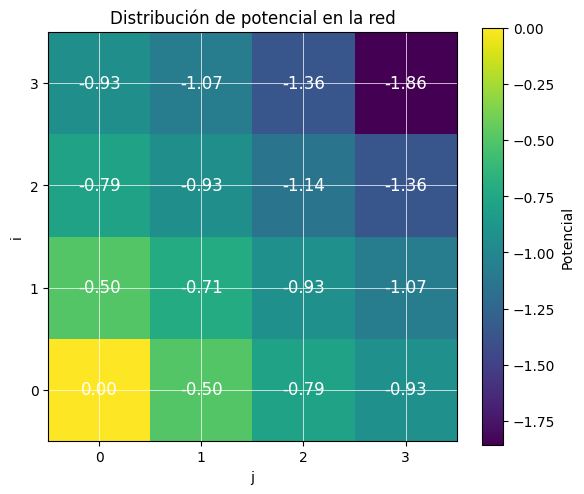


Corrientes hacia la derecha:
[[0.5        0.28571429 0.14285714]
 [0.21428571 0.21428571 0.14285714]
 [0.14285714 0.21428571 0.21428571]
 [0.14285714 0.28571429 0.5       ]]

Corrientes hacia arriba:
[[0.5        0.21428571 0.14285714 0.14285714]
 [0.28571429 0.21428571 0.21428571 0.28571429]
 [0.14285714 0.14285714 0.21428571 0.5       ]]

Verificación de Kirchhoff:
[[ 1.00000000e+00  1.11022302e-16  0.00000000e+00 -1.11022302e-16]
 [ 1.11022302e-16 -1.11022302e-16  0.00000000e+00  4.44089210e-16]
 [ 2.22044605e-16 -2.22044605e-16  1.11022302e-16 -4.44089210e-16]
 [-1.11022302e-16  0.00000000e+00 -2.22044605e-16 -1.00000000e+00]]


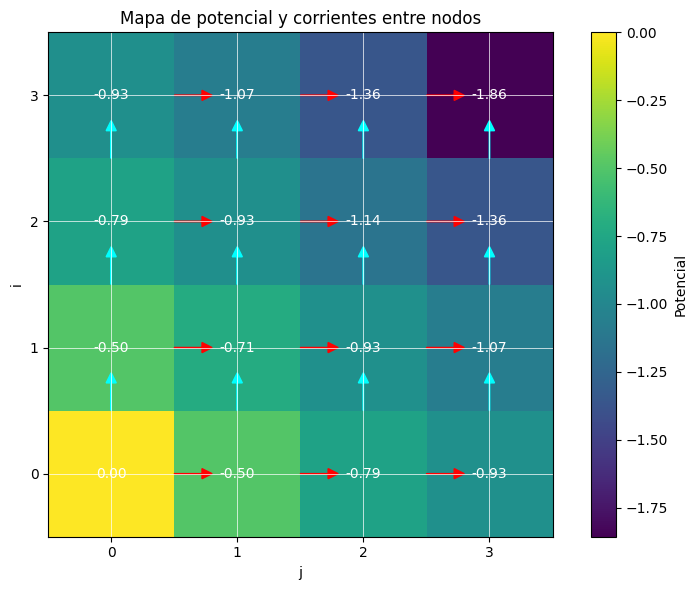

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Parámetros de la red
# =========================
N = 4
num_nodos = N * N

def idx(i, j):
    return i * N + j

# =========================
# 2. Construcción del laplaciano
# =========================
L = np.zeros((num_nodos, num_nodos))

for i in range(N):
    for j in range(N):
        nodo = idx(i, j)

        vecinos = []
        if i > 0:
            vecinos.append((i - 1, j))
        if i < N - 1:
            vecinos.append((i + 1, j))
        if j > 0:
            vecinos.append((i, j - 1))
        if j < N - 1:
            vecinos.append((i, j + 1))

        for vi, vj in vecinos:
            vecino = idx(vi, vj)
            G = 1.0  # conductancia unitaria

            L[nodo, nodo] += G
            L[nodo, vecino] -= G

# =========================
# 3. Vector de corrientes externas
# =========================
I_ext = np.zeros(num_nodos)
I_ext[idx(0, 0)] = 1.0
I_ext[idx(N - 1, N - 1)] = -1.0

# =========================
# 4. Fijar nodo de referencia
#    Tomamos V(0,0)=0
# =========================
L_reducida = L[1:, 1:]
I_reducida = I_ext[1:]

V_reducido = np.linalg.solve(L_reducida, I_reducida)

V = np.zeros(num_nodos)
V[1:] = V_reducido

V_grid = V.reshape((N, N))

print("Mapa de potencial:")
print(V_grid)

# =========================
# 5. Visualización del potencial
# =========================
plt.figure(figsize=(6, 5))
plt.imshow(V_grid, cmap='viridis', origin='lower')
plt.colorbar(label='Potencial')
plt.title('Distribución de potencial en la red')
plt.xlabel('j')
plt.ylabel('i')
plt.xticks(range(N))
plt.yticks(range(N))

for i in range(N):
    for j in range(N):
        plt.text(
            j, i, f"{V_grid[i, j]:.2f}",
            ha='center', va='center',
            color='white', fontsize=12
        )

plt.grid(color='white', linewidth=0.5)
plt.tight_layout()
plt.savefig('DistribucionPotencial.pdf', dpi=300, bbox_inches='tight')
plt.show()

# =========================
# 6. Corrientes en las aristas
# =========================
# Corriente horizontal: de (i,j) a (i,j+1)
I_right = np.zeros((N, N - 1))
for i in range(N):
    for j in range(N - 1):
        I_right[i, j] = V_grid[i, j] - V_grid[i, j + 1]

# Corriente vertical: de (i,j) a (i+1,j)
I_up = np.zeros((N - 1, N))
for i in range(N - 1):
    for j in range(N):
        I_up[i, j] = V_grid[i, j] - V_grid[i + 1, j]

print("\nCorrientes hacia la derecha:")
print(I_right)

print("\nCorrientes hacia arriba:")
print(I_up)

# =========================
# 7. Verificación de Kirchhoff
# =========================
I_check = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        suma = 0.0

        # corriente hacia derecha
        if j < N - 1:
            suma += V_grid[i, j] - V_grid[i, j + 1]

        # hacia izquierda
        if j > 0:
            suma += V_grid[i, j] - V_grid[i, j - 1]

        # hacia arriba
        if i < N - 1:
            suma += V_grid[i, j] - V_grid[i + 1, j]

        # hacia abajo
        if i > 0:
            suma += V_grid[i, j] - V_grid[i - 1, j]

        I_check[i, j] = suma

print("\nVerificación de Kirchhoff:")
print(I_check)

# =========================
# 8. Visualización del potencial + corrientes
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(V_grid, origin='lower', cmap='viridis')
plt.colorbar(label='Potencial')

for i in range(N):
    for j in range(N):
        plt.text(
            j, i, f"{V_grid[i, j]:.2f}",
            ha='center', va='center',
            color='white', fontsize=10
        )

# Flechas horizontales
for i in range(N):
    for j in range(N - 1):
        corriente = I_right[i, j]

        # punto medio del enlace horizontal
        x0 = j + 0.5
        y0 = i

        if corriente > 0:
            dx, dy = 0.30, 0.0
        else:
            dx, dy = -0.30, 0.0

        plt.arrow(
            x0, y0, dx, dy,
            head_width=0.08, head_length=0.08,
            fc='red', ec='red', length_includes_head=True
        )

# Flechas verticales
for i in range(N - 1):
    for j in range(N):
        corriente = I_up[i, j]

        # punto medio del enlace vertical
        x0 = j
        y0 = i + 0.5

        if corriente > 0:
            dx, dy = 0.0, 0.30
        else:
            dx, dy = 0.0, -0.30

        plt.arrow(
            x0, y0, dx, dy,
            head_width=0.08, head_length=0.08,
            fc='cyan', ec='cyan', length_includes_head=True
        )

plt.xticks(range(N))
plt.yticks(range(N))
plt.xlabel('j')
plt.ylabel('i')
plt.title('Mapa de potencial y corrientes entre nodos')
plt.grid(color='white', linewidth=0.5)
plt.tight_layout()
plt.show()